In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp
import numpy as np

import matplotlib.pyplot as plt

from flax import nnx

plt.style.use('pyloric_black.mplstyle')

Duplicate key in file 'pyloric_black.mplstyle', line 65 ('savefig.facecolor    : black       # Ensures black background when saving')


In [3]:
from diffusion_mri_models import Dti, Ball, Stick, add_mri_noise, normal_to_beta

In [36]:
from sympy import jn


class BallAndStick(nnx.Module, experimental_pytree=True):
    
    def __init__(self,num_sticks: int, rngs):
        self.num_sticks = num_sticks
        self.num_components = 1 + num_sticks + 1 # Ball + Sticks + Noise
        # Ball parameters
        self.theta_ball = nnx.Param(jax.random.normal(rngs.next(), (1)))
        self.phi_ball = nnx.Param(jax.random.normal(rngs.next(), (1)))

        self.thetas_stick = []
        self.phis_stick = []
    
        for i in range(num_sticks):
            self.thetas_stick.append(nnx.Param(jax.random.normal(rngs.next(), (3))))
            #if i < num_sticks-1:
            self.phis_stick.append(nnx.Param(jax.random.normal(rngs.next(), (1))))

        self.theta_sigma = nnx.Param(jax.random.normal(rngs.next(), (1)))

        

    def __call__(self, component_mask, bvals, bvecs, rng):
        ball = Ball.from_theta(self.theta_ball.value)
        sticks = [Stick.from_theta(theta) for theta in self.thetas_stick]


        phi0 = self.phi_ball.value
        phi1 = self.phis_stick[0].value
        phi2 = self.phis_stick[1].value 
        
        phis = jnp.concatenate([phi0, phi1, phi2])
        phis = jnp.where(component_mask[:-1] == 0, -jnp.inf, phis)
        phis_normalized = jax.nn.softmax(phis)
        phis_normalized = jnp.where(component_mask[:-1] == 0, 0, phis_normalized)
        
        S_ball = ball.signal(bvals, bvecs) * phis_normalized[0]
        S_total = S_ball

        for i, stick in enumerate(sticks):
            S_total += stick.signal(bvals, bvecs)*phis_normalized[i+1]
            

        std = jax.nn.sigmoid(self.theta_sigma.value)*0.1 * component_mask[-1]
        S_noisy = add_mri_noise(rng,S_total, std)

        return S_noisy


In [37]:
bvals = np.load('bvals.npy')
bvecs = np.load('bvecs.npy')

S_real = np.load("masked_data.npy")
b0_mask = bvals == 0

S0_real = np.mean(S_real[...,b0_mask], axis=-1, keepdims=True)
S_real = np.nan_to_num(S_real / S0_real)

/tmp/ipykernel_28404/2037590477.py:8: RuntimeWarning: divide by zero encountered in divide
  S_real = np.nan_to_num(S_real / S0_real)
/tmp/ipykernel_28404/2037590477.py:8: RuntimeWarning: invalid value encountered in divide
  S_real = np.nan_to_num(S_real / S0_real)


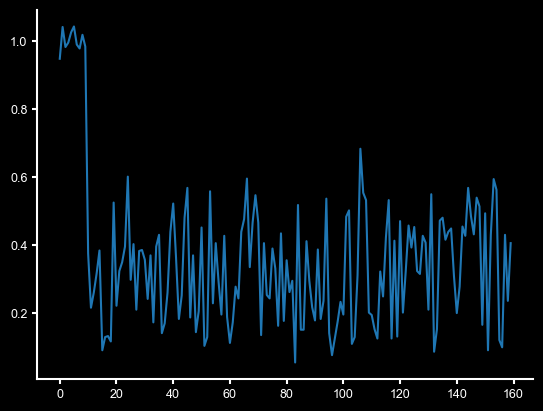

In [38]:
plt.plot(S_real[20,20,30])

In [39]:
simulator = BallAndStick(2, nnx.Rngs(10))

# bvals = jnp.array([0]*10 + [1000]*90)
# bvecs = jax.random.normal(jax.random.key(1), (100,3))
component_mask = jnp.array([1]*simulator.num_components)
component_mask

Array([1, 1, 1, 1], dtype=int32)

In [40]:
component_mask = jnp.array([1,1,1,1])
s = simulator(component_mask, bvals, bvecs, jax.random.key(15))

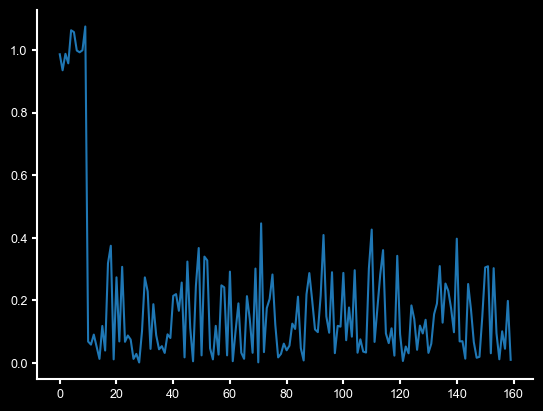

In [41]:
plt.plot(s)

In [42]:
graphdef, thetas = nnx.split(simulator, nnx.Param)
flat_thetas, unflatten = jax.flatten_util.ravel_pytree(thetas)

NUM_AQUISITIONS = len(bvals)

def generate_data(key):
    rng_component_mask, rng_params, rng_simulator = jax.random.split(key,3)
    component_mask = jax.random.bernoulli(rng_component_mask, 0.3, (simulator.num_components,))
    params = jax.random.normal(rng_params, flat_thetas.shape)
    params = unflatten(params)
    f = nnx.merge(graphdef, params)
    S = f(component_mask, bvals, bvecs, rng_simulator)
    return component_mask, params, S

flat_thetas


Array([-0.134, -0.513, -0.228,  0.624, -0.038,  0.039,  1.615, -1.961,
       -0.807, -0.387, -0.23 ], dtype=float32)

In [100]:
from functools import partial


@partial(jax.jit, static_argnums=(1,))  
def batch_sampler(key, batch_size=512):
    keys = jax.random.split(key, batch_size)
    components, thetas, signal= jax.vmap(lambda k:generate_data(k))(keys)
    xs = signal.reshape((batch_size, -1))
    return components, thetas, xs

def train_data_generator(key, batch_size):
    while True:
        key, subkey = jax.random.split(key)
        yield batch_sampler(subkey, batch_size)

train_data = train_data_generator(jax.random.PRNGKey(0), 1024)

In [101]:
from models import ModelIdentificationDecoder, MLP, Simformer, PyTreeTokenizer, EDM

In [102]:
import jax.flatten_util


_, thetas, xs = next(train_data)

thetas_flatten, tree = jax.tree_util.tree_flatten(thetas)
thetas_flat = jnp.concatenate(thetas_flatten, axis=-1)

In [103]:
from ast import mod
from pyexpat import model


class EmbeddingNet(nnx.Module, experimental_pytree=True):
    def __init__(self, rngs):
        self.data_embedding = MLP([NUM_AQUISITIONS, 200,200,80], rngs=rngs)
        self.model_embeding = MLP([4, 100, 20], rngs=rngs)
        
    def __call__(self, x):
        model_componets, data = x
        data_embedding = self.data_embedding(data)
        model_embedding = self.model_embeding(model_componets.astype(jnp.float32))
        return jnp.concatenate([data_embedding, model_embedding], axis=-1)

In [104]:
#embedding_net = MLP([NUM_AQUISITIONS, 200,200,100], rngs=nnx.Rngs(0))
embedding_net = EmbeddingNet(nnx.Rngs(0))

dims_by_component = [1,1,1,1,1,3,3]
node_ids = list(range(len(dims_by_component)))
embed_nets = [nnx.Linear(dims_by_component[i], 100, rngs=nnx.Rngs(1),use_bias=False) for i in range(len(dims_by_component))]
decode_nets = [nnx.Linear(200, dims_by_component[i], rngs=nnx.Rngs(2),use_bias=False) for i in range(len(dims_by_component))]

tokenizer = PyTreeTokenizer(dims_by_component, embed_nets, decode_nets, rngs=nnx.Rngs(3), cond_dim=0, id_dim=100)
simformer = Simformer(tokenizer, nnx.Rngs(4), model_dim=200, context_embed=embedding_net, condition_dim=0, num_layers=5)

model = EDM(simformer)
params = nnx.state(model, nnx.Param)

In [116]:
def components_to_params_mask(component_mask):
    mask_params = jnp.zeros((7,), dtype=jnp.bool_)
    mask_params = mask_params.at[0].set(component_mask[0]) # Ball volume fraction
    mask_params = mask_params.at[3].set(component_mask[0]) # Ball phi
    mask_params = mask_params.at[4].set(component_mask[3]) # noise std
    mask_params = mask_params.at[1].set(component_mask[1]) # Stick1 volume fraction
    mask_params = mask_params.at[5].set(component_mask[1]) # Stick1 phi
    mask_params = mask_params.at[2].set(component_mask[2]) # Stick2 volume fraction
    mask_params = mask_params.at[6].set(component_mask[2]) # Stick2 phi
    # Summarize shared parameters
    
    return mask_params


def attention_mask(component_mask):
    param_mask = components_to_params_mask(component_mask)

    # Only active params can have cross attention
    mask = jnp.outer(param_mask, param_mask)
    mask = mask | jnp.eye(mask.shape[0], dtype=jnp.bool_)
    return mask
    

In [117]:
components, thetas, xs = next(train_data)

In [118]:
import optax 

scheduler_lr = optax.cosine_onecycle_schedule(20_000, 5e-4)
optimizer = optax.chain(optax.adaptive_grad_clip(10.), optax.ema(0.01), optax.adam(scheduler_lr))

@jax.jit
def loss_fn(params, data, rng):
    components, thetas, xs = data
    thetas_flatten, tree = jax.tree_util.tree_flatten(thetas)
    thetas_flat = jnp.concatenate(thetas_flatten, axis=-1)
    attention_masks = jax.vmap(attention_mask)(components)
    attention_masks = attention_masks[:, None,...]
    loss = model.loss(params, rng=rng, data=thetas_flat, node_ids=node_ids, condition_mask=None,context=(components,xs), attention_mask=attention_masks)


    return loss

@jax.jit
def update(params, opt_state, data, rng):
    grads = jax.grad(loss_fn)(params, data, rng)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state



In [119]:
opt_state = optimizer.init(params)

In [120]:
key = jax.random.PRNGKey(1)
for i in range(20_000):
    data = next(train_data)
    key, subkey = jax.random.split(key)
    params, opt_state = update(params, opt_state, data, subkey)
    if i % 100 == 0:
        print(loss_fn(params, data, subkey))

(1024, 1, 100) (1024, 1, 100)
(1024, 1, 200)
17.314388
11.230305
10.9826765
10.853853
11.097462
10.985504
10.975739
10.950338
10.975349
10.975182
10.848381
10.852055
11.027594
10.924128
11.02585
10.751463
10.656152
10.953228
10.702581
10.559219
10.928705
10.55068
10.485804
10.877899
10.330857
10.271405
10.286556
10.374554
10.062397
10.383088
10.137933
10.421353
9.929693
10.0892935
10.058563
10.057434
10.1597
10.164738
10.13505
9.836237
9.854636
9.894781
9.819778
9.931738
10.032024
9.645884
10.020093
9.759917
9.969434
9.748582
9.849677
9.779622
9.911102
9.898581
9.677385
9.655637
9.608753
9.855112
9.65803
9.699839
9.918395
9.755508
9.667851
9.860853
9.5962105
9.7273035
10.029395
9.679509
9.613846
9.6523285
9.645381
9.436493
9.767543
9.348282
9.663214
9.604427
9.54695
9.593613
9.658276
9.700296
9.625865
9.690001
9.660556
9.361492
9.561205
9.640626
9.711243
9.397886
9.645943
9.536441
9.497713
9.622153
9.593457
9.620499
9.540342
9.687464
9.364004
9.639292
9.313175
9.431334
9.526503
9.58390

In [121]:
nnx.update(model, params)

In [122]:
components, thetas, xs = next(train_data)

In [123]:
from probjax.utils.odeint import odeint

def sample(rng, context):
    eps = jax.random.normal(rng, (11,)) * model.marginal_std(model.max_noise)
    ts = model.solve_schedule(100)
    mask = attention_mask(context[0])

    def drift(t, x):
        t = jnp.atleast_1d(t)
        f = model.drift(t,x)
        g = model.diffusion(t, x)
        score = model.score(t,x, context=context, node_ids=node_ids, condition_mask=None, attention_mask=mask)
        return (f -0.5*g**2*score).reshape(x.shape)

    return odeint(drift, eps,ts, method="heun")[-1]


from probjax.utils.sdeint import sdeint

def sample(rng, context):

    rng_init, rng_sample = jax.random.split(rng)
    eps = jax.random.normal(rng_init, (11,))  * model.marginal_std(model.max_noise)
    ts = model.solve_schedule(200)
    mask = attention_mask(context[0])

    def drift(t, x):
        t = jnp.atleast_1d(t)
        f = model.drift(t,x)
        g = model.diffusion(t,x)
        score = model.score(t,x, context=context, node_ids=node_ids, condition_mask=None, attention_mask=mask)

        drift_backward = f - g**2 * score
        return drift_backward
    
    def diffusion(t, x):
        t = jnp.atleast_1d(t)
        g = model.diffusion(t,x)
        return g
    
    return sdeint(rng_sample,drift, diffusion, eps, ts, method="euler_maruyama")[-1]
    

    
    

In [124]:
thetas_flatten, tree = jax.tree_util.tree_flatten(thetas)
thetas_flat = jnp.concatenate(thetas_flatten, axis=-1)

In [125]:
thetas_flat.shape

(1024, 11)

In [146]:
idx = 1
print(components[idx])

def components_to_full_params_mask(component_mask):
    mask_params = jnp.zeros((11,), dtype=jnp.bool_)
    mask_params = mask_params.at[0].set(component_mask[0]) # Ball volume fraction
    mask_params = mask_params.at[3].set(component_mask[0]) # Ball phi
    mask_params = mask_params.at[4].set(component_mask[3]) # noise std
    mask_params = mask_params.at[1].set(component_mask[1]) # Stick1 volume fraction
    mask_params = mask_params.at[5:8].set(component_mask[1]) # Stick1 phi
    mask_params = mask_params.at[2].set(component_mask[2]) # Stick2 volume fraction
    mask_params = mask_params.at[8:11].set(component_mask[2]) # Stick2 phi
    # Summarize shared parameters
    
    return mask_params

params_mask = components_to_full_params_mask(components[idx])

[ True False  True  True]


In [147]:
thetas_pred = jax.vmap(lambda k: sample(k, (components[idx],xs[idx])))(jax.random.split(jax.random.PRNGKey(0), 2000))

(1, 100) (1, 100)
(1, 200)


In [151]:
from sbi.analysis import pairplot
thetas_pred_red = thetas_pred[:,params_mask]

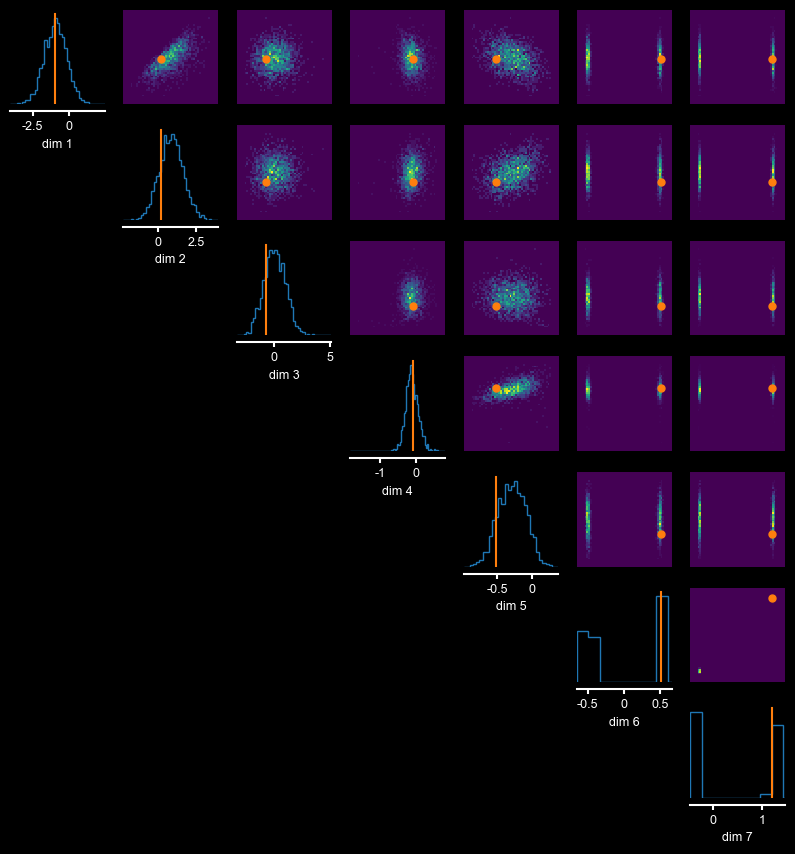

In [156]:
fig, axes = pairplot(thetas_pred_red, points=thetas_flat[idx][params_mask][None])
fig.savefig("figures/pairplot_ball_and_one_stick.png")

In [157]:
def pred(key, thetas):
    params = unflatten(thetas)
    f = nnx.merge(graphdef, params)
    S = f(component_mask, bvals, bvecs, key)
    return S

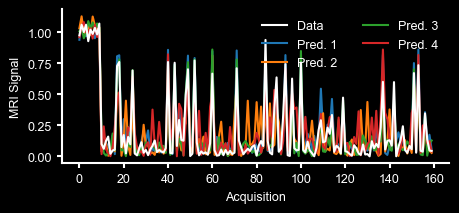

In [158]:
from matplotlib.pylab import f


S_pred = jax.vmap(pred)(jax.random.split(jax.random.key(0),2000), thetas_pred)


fig = plt.figure(figsize=(5,2))
l2 = plt.plot(S_pred[::500].T)
l1 = plt.plot(xs[idx], color="white")

plt.ylabel("MRI Signal")
plt.xlabel("Acquisition")

plt.legend([l1[0]] + l2, ["Data"] + [f"Pred. {i}" for i in range(1, 5)], ncol=2)
fig.savefig("figures/pred_ball_and_one_stick.png")

In [163]:
import dipy
from dipy.viz import window, actor

/root/miniconda3/envs/probjax_new/lib/python3.12/site-packages/dipy/viz/__init__.py:22: UserWarning: You do not have FURY installed. Therefore, 3D visualization functions will not work for you. Please install or upgrade FURY using pip install -U furyFor detailed installation instructions visit: https://fury.gl/
  warnings.warn(


ImportError: cannot import name 'window' from 'dipy.viz' (/root/miniconda3/envs/probjax_new/lib/python3.12/site-packages/dipy/viz/__init__.py)